# 🔬 Lab 2: Classification Models I
## Logistic Regression & K-Nearest Neighbors (KNN)

---

### 📚 Learning Objectives
By the end of this lab, you will be able to:
- Implement Logistic Regression for binary classification
- Understand the sigmoid function and probability predictions
- Build K-Nearest Neighbors (KNN) classifiers
- Tune the K hyperparameter for optimal performance
- Compare model performance using accuracy metrics
- Visualize decision boundaries

### ⏱️ Estimated Time: 60-75 minutes

---

**Key Concept:** Classification predicts categorical outcomes (Yes/No, Spam/Not Spam, etc.)

## Part 1: Setup and Data Preparation

In [1]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn - Data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scikit-learn - Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn - Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [33]:
# ============================================================
# STEP 2: Create Bank Customer Subscription Dataset
# ============================================================
# We'll create a realistic bank marketing dataset
# Goal: Predict if a customer will subscribe to a term deposit
# This is inspired by real-world bank telemarketing campaigns

np.random.seed(42)
n_samples = 1000

# Generate customer features
data = {
    # Customer Demographics
    'age': np.random.randint(18, 70, n_samples),
    'balance': np.random.exponential(70, n_samples).astype(int),  # Account balance
    'duration': np.random.randint(20, 60, n_samples),  # Last contact duration (seconds)
    'campaign_contacts': np.random.randint(1, 115, n_samples),  # Number of contacts
    'previous_contacts': np.random.randint(0, 110, n_samples),  # Previous campaign contacts
    'days_since_contact': np.random.randint(-1, 3165, n_samples),  # Days since last contact (-1 = never)

    # Customer Engagement Metrics
    'website_visits': np.random.randint(0, 30, n_samples),  # Monthly website visits
    'email_open_rate': np.random.uniform(0, 1, n_samples),  # Email engagement (0-1)
    'customer_tenure': np.random.randint(0, 20, n_samples),  # Years as customer
    'num_products': np.random.randint(1, 5, n_samples),  # Number of bank products
}

df = pd.DataFrame(data)

# Create target variable based on logical rules
# Higher probability of subscription for:
# - Longer call duration, higher balance, more website visits, better email engagement
subscription_prob = (
    0.1 +  # Base probability
    (df['duration'] > 300) * 0.25 +  # Longer calls indicate interest
    (df['balance'] > 5000) * 0.15 +  # Higher balance = more likely
    (df['website_visits'] > 20) * 0.15 +  # Engaged customers
    (df['email_open_rate'] > 0.5) * 0.1 +  # Email engagement
    (df['previous_contacts'] > 0) * 0.1 +  # Previous contact history
    (df['customer_tenure'] > 5) * 0.1  # Loyal customers
)

# Add some noise
subscription_prob = np.clip(subscription_prob + np.random.uniform(-0.1, 0.1, n_samples), 0, 1)

# Generate binary target
df['subscribed'] = (np.random.random(n_samples) < subscription_prob).astype(int)
df['subscription_status'] = df['subscribed'].map({0: 'No', 1: 'Yes'})

print("🏦 Bank Customer Subscription Dataset Created!")
print("=" * 60)
print(f"Total customers: {len(df)}")
print(f"Number of features: {len(df.columns) - 2}")
print(f"\nTarget: Will customer subscribe to term deposit?")
print(f"\nClass distribution:")
print(df['subscription_status'].value_counts())

🏦 Bank Customer Subscription Dataset Created!
Total customers: 1000
Number of features: 10

Target: Will customer subscribe to term deposit?

Class distribution:
subscription_status
No     625
Yes    375
Name: count, dtype: int64


In [34]:
# ============================================================
# STEP 3: Explore the Dataset
# ============================================================

print("📋 First 5 rows of the dataset:")
df.head()

📋 First 5 rows of the dataset:


,age,balance,duration,campaign_contacts,previous_contacts,days_since_contact,website_visits,email_open_rate,customer_tenure,num_products,subscribed,subscription_status
0,56,53,47,105,1,3108,19,0.038958,0,1,0,No
1,69,19,59,49,21,1233,5,0.391811,2,3,0,No
2,46,21,24,13,56,2490,16,0.802402,6,3,0,No
3,32,33,39,34,100,1349,9,0.341244,14,2,0,No
4,60,1,59,109,71,2807,27,0.444183,18,3,1,Yes


In [35]:
# Statistical summary
print("\n📊 Statistical Summary:")
df.describe()


📊 Statistical Summary:


,age,balance,duration,campaign_contacts,previous_contacts,days_since_contact,website_visits,email_open_rate,customer_tenure,num_products,subscribed
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,69.269000,39.741000,58.279000,53.922000,1550.469000,15.051000,0.493967,9.526000,2.432000,0.375000
std,14.99103,70.015132,11.502792,32.960029,30.897712,902.618462,8.581961,0.288887,5.670933,1.121889,0.484365
min,18.00000,0.000000,20.000000,1.000000,0.000000,4.000000,0.000000,0.000598,0.000000,1.000000,0.000000
25%,31.00000,18.000000,30.000000,29.000000,27.000000,793.000000,8.000000,0.246385,5.000000,1.000000,0.000000
50%,44.00000,48.500000,40.000000,57.500000,54.000000,1536.500000,15.000000,0.481289,10.000000,2.000000,0.000000
75%,56.00000,93.000000,49.000000,87.000000,80.000000,2310.750000,22.000000,0.741856,15.000000,3.000000,1.000000
max,69.00000,520.000000,59.000000,114.000000,109.000000,3163.000000,29.000000,0.998793,19.000000,4.000000,1.000000


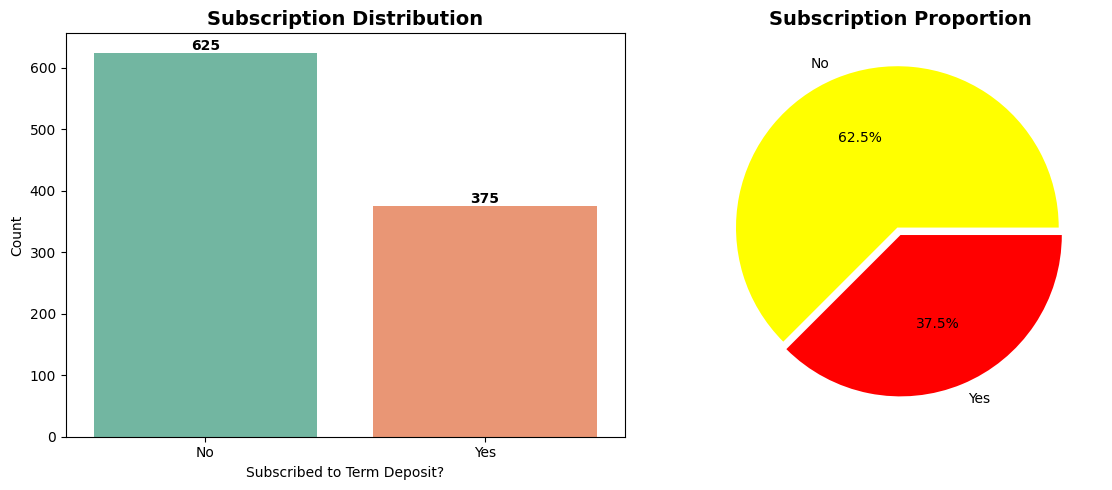


💡 This is a typical imbalanced dataset in marketing - fewer customers subscribe!


In [40]:
# ============================================================
# STEP 4: Visualize Class Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df, x='subscription_status', palette='Set2', ax=axes[0])
axes[0].set_title('Subscription Distribution', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Subscribed to Term Deposit?')
axes[0].set_ylabel('Count')

# Add count labels on bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
df['subscription_status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['yellow', 'red'],
    ax=axes[1],
    explode=(0.05, 0)
)
axes[1].set_title('Subscription Proportion', fontweight='bold', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n💡 This is a typical imbalanced dataset in marketing - fewer customers subscribe!")

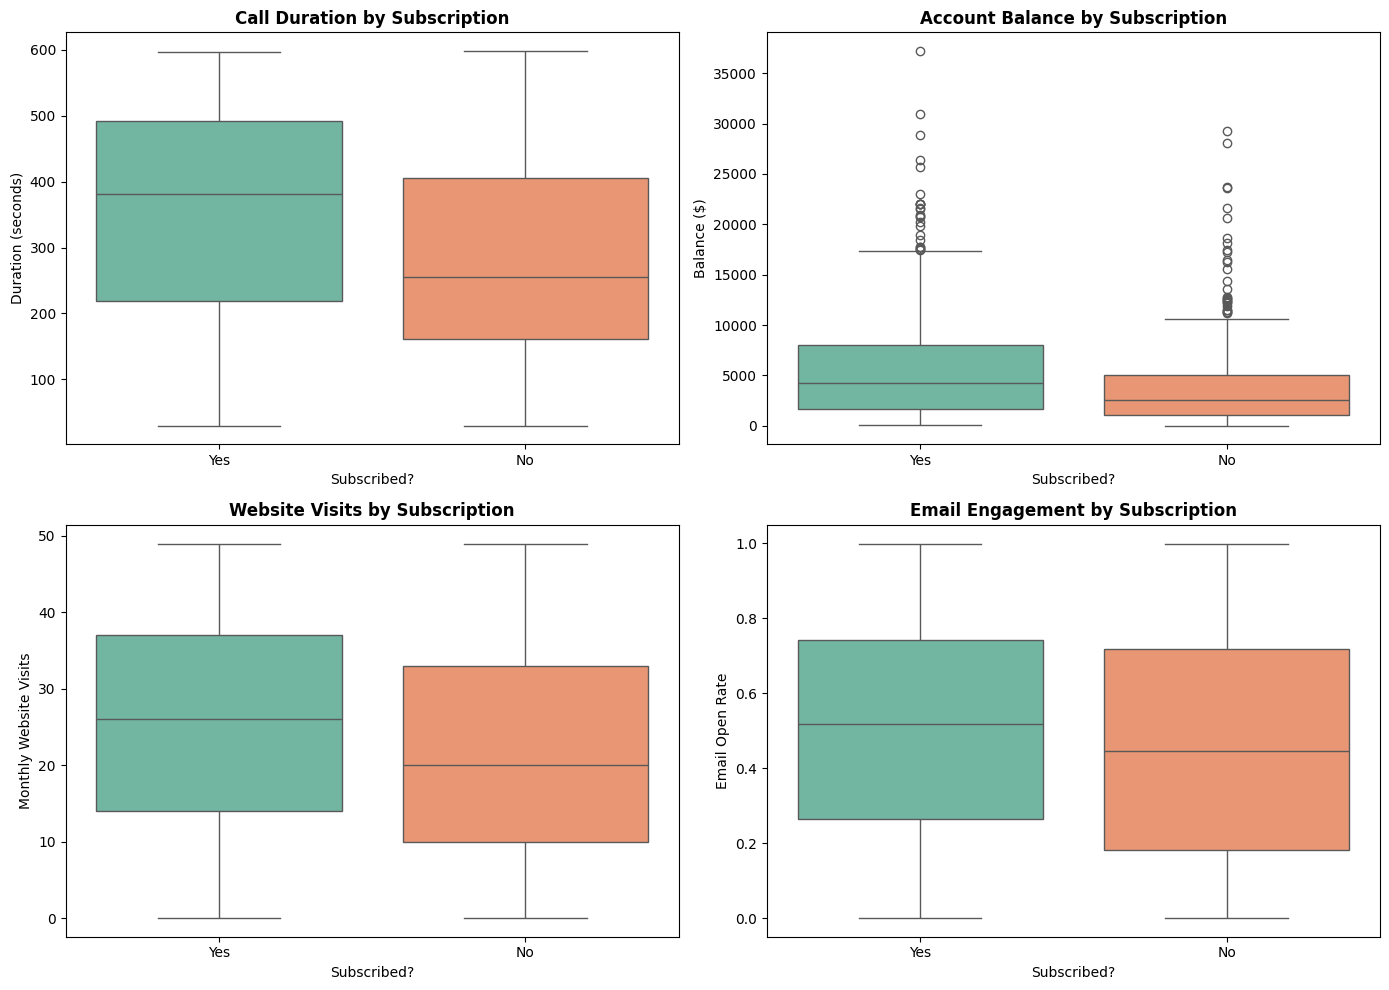


💡 Key Observations:
   • Longer call duration → Higher subscription rate
   • Higher balance → Higher subscription rate
   • More website visits → Higher subscription rate


In [6]:
# ============================================================
# STEP 5: Explore Feature Relationships
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Duration vs Subscription
sns.boxplot(data=df, x='subscription_status', y='duration', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Call Duration by Subscription', fontweight='bold')
axes[0,0].set_xlabel('Subscribed?')
axes[0,0].set_ylabel('Duration (seconds)')

# Balance vs Subscription
sns.boxplot(data=df, x='subscription_status', y='balance', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Account Balance by Subscription', fontweight='bold')
axes[0,1].set_xlabel('Subscribed?')
axes[0,1].set_ylabel('Balance ($)')

# Website visits vs Subscription
sns.boxplot(data=df, x='subscription_status', y='website_visits', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Website Visits by Subscription', fontweight='bold')
axes[1,0].set_xlabel('Subscribed?')
axes[1,0].set_ylabel('Monthly Website Visits')

# Email open rate vs Subscription
sns.boxplot(data=df, x='subscription_status', y='email_open_rate', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Email Engagement by Subscription', fontweight='bold')
axes[1,1].set_xlabel('Subscribed?')
axes[1,1].set_ylabel('Email Open Rate')

plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("   • Longer call duration → Higher subscription rate")
print("   • Higher balance → Higher subscription rate")
print("   • More website visits → Higher subscription rate")

In [7]:
# ============================================================
# STEP 6: Prepare Data for Modeling
# ============================================================

# Select features (exclude target columns)
feature_columns = ['age', 'balance', 'duration', 'campaign_contacts',
                   'previous_contacts', 'days_since_contact', 'website_visits',
                   'email_open_rate', 'customer_tenure', 'num_products']

X = df[feature_columns]
y = df['subscribed']

# Split into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class proportions
)

print("📊 Data Split Summary:")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nFeatures: {X_train.shape[1]}")
print(f"\nTraining class distribution:")
print(f"   No subscription: {(y_train == 0).sum()}")
print(f"   Subscribed: {(y_train == 1).sum()}")

📊 Data Split Summary:
Training set: 800 samples (80%)
Test set: 200 samples (20%)

Features: 10

Training class distribution:
   No subscription: 332
   Subscribed: 468


In [8]:
# ============================================================
# STEP 7: Feature Scaling
# ============================================================
# IMPORTANT: Scale features for better model performance
# Especially crucial for KNN (distance-based algorithm)

scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")
print("\nBefore scaling (balance feature):")
print(f"  Mean: {X_train['balance'].mean():.2f}, Std: {X_train['balance'].std():.2f}")
print("\nAfter scaling (balance feature):")
print(f"  Mean: {X_train_scaled[:, 1].mean():.2f}, Std: {X_train_scaled[:, 1].std():.2f}")

print("\n💡 Why Scale?")
print("   • Balance ranges from 0 to 30,000+")
print("   • Email open rate ranges from 0 to 1")
print("   • Without scaling, balance would dominate distance calculations in KNN!")

✅ Features scaled using StandardScaler

Before scaling (balance feature):
  Mean: 4875.20, Std: 4906.29

After scaling (balance feature):
  Mean: 0.00, Std: 1.00

💡 Why Scale?
   • Balance ranges from 0 to 30,000+
   • Email open rate ranges from 0 to 1
   • Without scaling, balance would dominate distance calculations in KNN!


## Part 2: Understanding the Sigmoid Function

Before building Logistic Regression, let's understand its core: the **Sigmoid Function**

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

This function converts any real number to a probability between 0 and 1.

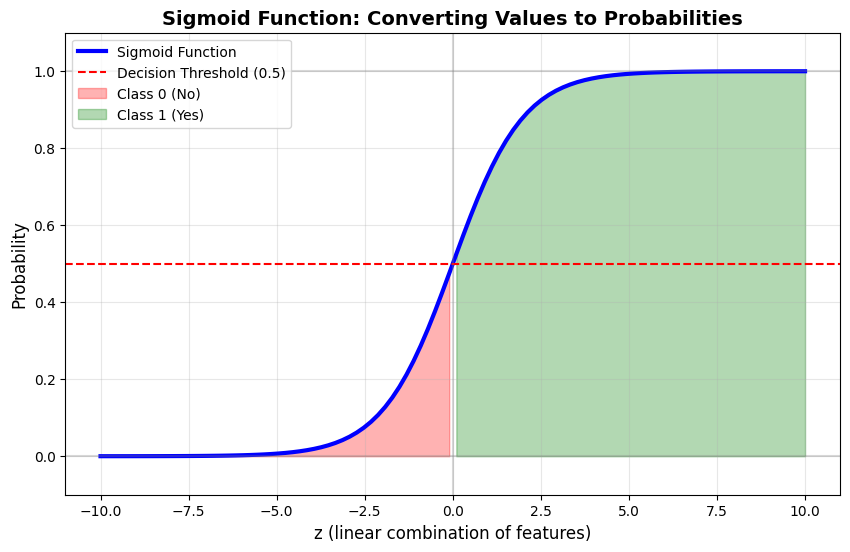

💡 Key Properties of Sigmoid:
   • Output is always between 0 and 1 (perfect for probability!)
   • When z = 0, probability = 0.5 (decision boundary)
   • Very negative z → probability ≈ 0
   • Very positive z → probability ≈ 1


In [9]:
# ============================================================
# STEP 8: Visualize the Sigmoid Function
# ============================================================

def sigmoid(z):
    """The sigmoid function - converts any number to probability [0, 1]"""
    return 1 / (1 + np.exp(-z))

# Generate values
z = np.linspace(-10, 10, 100)
probabilities = sigmoid(z)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(z, probabilities, 'b-', linewidth=3, label='Sigmoid Function')

# Add reference lines
plt.axhline(y=0.5, color='r', linestyle='--', label='Decision Threshold (0.5)')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axhline(y=1, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

# Shade regions
plt.fill_between(z[z < 0], probabilities[z < 0], alpha=0.3, color='red', label='Class 0 (No)')
plt.fill_between(z[z >= 0], probabilities[z >= 0], alpha=0.3, color='green', label='Class 1 (Yes)')

plt.xlabel('z (linear combination of features)', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Sigmoid Function: Converting Values to Probabilities', fontweight='bold', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.show()

print("💡 Key Properties of Sigmoid:")
print("   • Output is always between 0 and 1 (perfect for probability!)")
print("   • When z = 0, probability = 0.5 (decision boundary)")
print("   • Very negative z → probability ≈ 0")
print("   • Very positive z → probability ≈ 1")

## Part 3: Logistic Regression

In [10]:
# ============================================================
# STEP 9: Train Logistic Regression Model
# ============================================================

print("🎯 Training Logistic Regression Model")
print("=" * 60)

# Create and train the model
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000  # Ensure convergence
)

# Fit the model to training data
log_reg.fit(X_train_scaled, y_train)

print("✅ Model trained successfully!")
print(f"\nModel Parameters:")
print(f"   • Number of features: {log_reg.n_features_in_}")
print(f"   • Classes: {log_reg.classes_}")

🎯 Training Logistic Regression Model
✅ Model trained successfully!

Model Parameters:
   • Number of features: 10
   • Classes: [0 1]


In [11]:
# ============================================================
# STEP 10: Make Predictions
# ============================================================

# Predict class labels (0 or 1)
y_pred_log = log_reg.predict(X_test_scaled)

# Predict probabilities
y_prob_log = log_reg.predict_proba(X_test_scaled)

print("📊 Prediction Examples (first 10 test samples):")
print("=" * 70)
print(f"{'Actual':<10} {'Predicted':<12} {'P(No)':<12} {'P(Yes)':<12} {'Correct?':<10}")
print("-" * 70)

for i in range(10):
    actual = 'Yes' if y_test.iloc[i] == 1 else 'No'
    pred = 'Yes' if y_pred_log[i] == 1 else 'No'
    correct = '✅' if y_test.iloc[i] == y_pred_log[i] else '❌'
    print(f"{actual:<10} {pred:<12} {y_prob_log[i][0]:<12.4f} {y_prob_log[i][1]:<12.4f} {correct:<10}")

📊 Prediction Examples (first 10 test samples):
Actual     Predicted    P(No)        P(Yes)       Correct?  
----------------------------------------------------------------------
No         Yes          0.4426       0.5574       ❌         
No         No           0.5453       0.4547       ✅         
Yes        Yes          0.2130       0.7870       ✅         
Yes        Yes          0.2124       0.7876       ✅         
No         No           0.5167       0.4833       ✅         
No         Yes          0.3748       0.6252       ❌         
Yes        Yes          0.4778       0.5222       ✅         
No         Yes          0.4007       0.5993       ❌         
No         Yes          0.4178       0.5822       ❌         
Yes        Yes          0.3490       0.6510       ✅         


📈 Logistic Regression Performance

🎯 Accuracy: 0.6400 (64.00%)

📊 Confusion Matrix:
[[33 50]
 [22 95]]


<Figure size 800x600 with 0 Axes>

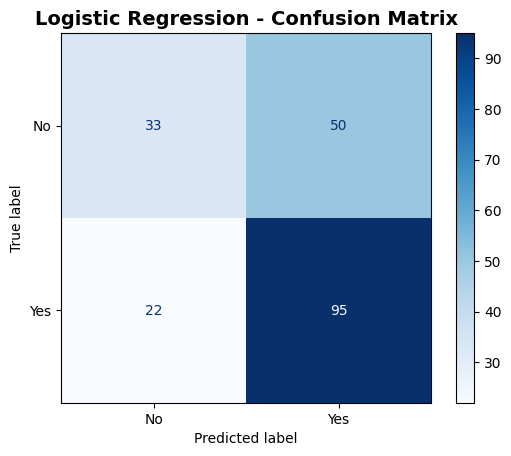


💡 Reading the Confusion Matrix:
   • True Negatives (No → No): 33
   • False Positives (No → Yes): 50
   • False Negatives (Yes → No): 22
   • True Positives (Yes → Yes): 95


In [12]:
# ============================================================
# STEP 11: Evaluate Model Performance
# ============================================================

# Calculate accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)

print("📈 Logistic Regression Performance")
print("=" * 60)
print(f"\n🎯 Accuracy: {accuracy_log:.4f} ({accuracy_log*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

print("\n📊 Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix', fontweight='bold', fontsize=14)
plt.show()

print("\n💡 Reading the Confusion Matrix:")
print(f"   • True Negatives (No → No): {cm[0,0]}")
print(f"   • False Positives (No → Yes): {cm[0,1]}")
print(f"   • False Negatives (Yes → No): {cm[1,0]}")
print(f"   • True Positives (Yes → Yes): {cm[1,1]}")

In [13]:
# ============================================================
# STEP 12: Detailed Classification Report
# ============================================================

print("📋 Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_log, target_names=['No', 'Yes']))

print("💡 Metrics Explained:")
print("   • Precision: Of all predicted 'Yes', how many were actually 'Yes'?")
print("   • Recall: Of all actual 'Yes', how many did we predict as 'Yes'?")
print("   • F1-Score: Harmonic mean of Precision and Recall")

📋 Classification Report:
              precision    recall  f1-score   support

          No       0.60      0.40      0.48        83
         Yes       0.66      0.81      0.73       117

    accuracy                           0.64       200
   macro avg       0.63      0.60      0.60       200
weighted avg       0.63      0.64      0.62       200

💡 Metrics Explained:
   • Precision: Of all predicted 'Yes', how many were actually 'Yes'?
   • Recall: Of all actual 'Yes', how many did we predict as 'Yes'?
   • F1-Score: Harmonic mean of Precision and Recall


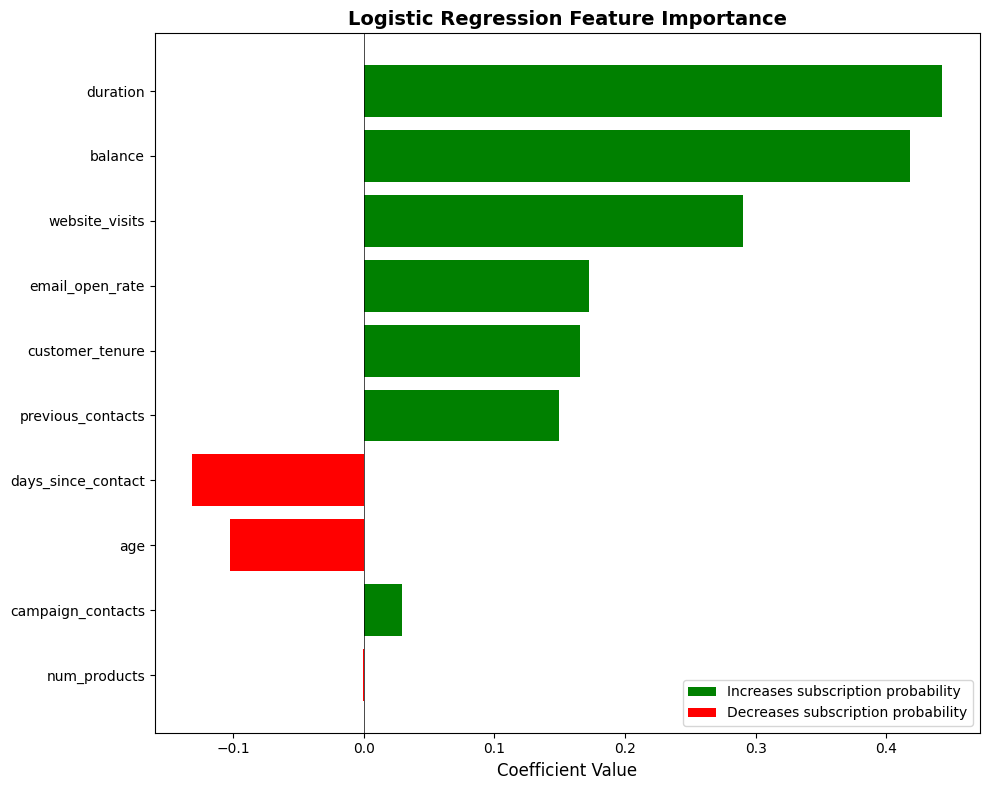


💡 Interpretation:
   • Positive coefficient: Higher value → Higher probability of subscription
   • Negative coefficient: Higher value → Lower probability of subscription

   Top factors increasing subscription:
      • website_visits: 0.2904
      • balance: 0.4183
      • duration: 0.4429


In [14]:
# ============================================================
# STEP 13: Analyze Feature Importance
# ============================================================
# In Logistic Regression, coefficients indicate feature importance

# Get coefficients
coefficients = log_reg.coef_[0]

# Create DataFrame for visualization
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Logistic Regression Feature Importance', fontweight='bold', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Increases subscription probability'),
                   Patch(facecolor='red', label='Decreases subscription probability')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   • Positive coefficient: Higher value → Higher probability of subscription")
print("   • Negative coefficient: Higher value → Lower probability of subscription")
print("\n   Top factors increasing subscription:")
top_positive = feature_importance[feature_importance['Coefficient'] > 0].tail(3)
for _, row in top_positive.iterrows():
    print(f"      • {row['Feature']}: {row['Coefficient']:.4f}")

## Part 4: K-Nearest Neighbors (KNN)

KNN is a simple yet powerful algorithm:
1. Find the K nearest neighbors to a new data point
2. Take a majority vote among neighbors
3. Assign the most common class

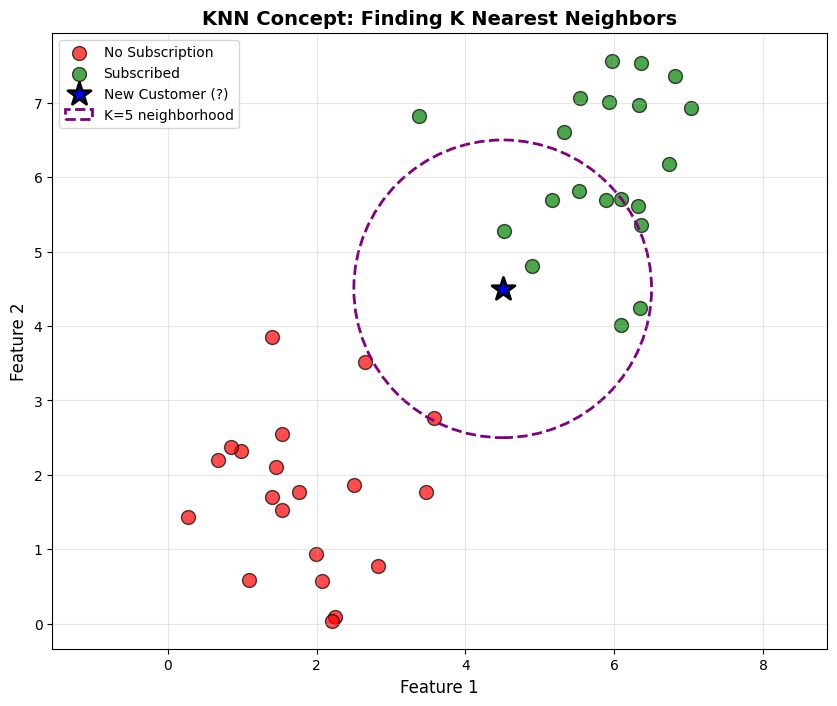

💡 KNN Concept:
   1. New customer (★) needs to be classified
   2. Find K nearest neighbors (points inside dashed circle)
   3. Take majority vote: More green → Subscribed, More red → No subscription


In [15]:
# ============================================================
# STEP 14: Visualize KNN Concept
# ============================================================

# Create a simple 2D example
np.random.seed(42)

# Generate sample points
class_0 = np.random.randn(20, 2) + np.array([2, 2])
class_1 = np.random.randn(20, 2) + np.array([6, 6])
new_point = np.array([[4.5, 4.5]])

plt.figure(figsize=(10, 8))

# Plot classes
plt.scatter(class_0[:, 0], class_0[:, 1], c='red', s=100, label='No Subscription', alpha=0.7, edgecolor='black')
plt.scatter(class_1[:, 0], class_1[:, 1], c='green', s=100, label='Subscribed', alpha=0.7, edgecolor='black')

# Plot new point
plt.scatter(new_point[0, 0], new_point[0, 1], c='blue', s=300, marker='*',
            label='New Customer (?)', edgecolor='black', linewidth=2)

# Draw circle for K=5 nearest neighbors
circle = plt.Circle((4.5, 4.5), 2, fill=False, linestyle='--', color='purple', linewidth=2, label='K=5 neighborhood')
plt.gca().add_patch(circle)

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('KNN Concept: Finding K Nearest Neighbors', fontweight='bold', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print("💡 KNN Concept:")
print("   1. New customer (★) needs to be classified")
print("   2. Find K nearest neighbors (points inside dashed circle)")
print("   3. Take majority vote: More green → Subscribed, More red → No subscription")

In [16]:
# ============================================================
# STEP 15: Train KNN Model (K=5)
# ============================================================

print("🎯 Training KNN Model (K=5)")
print("=" * 60)

# Create and train KNN
knn = KNeighborsClassifier(
    n_neighbors=5,  # K=5
    metric='euclidean'  # Distance metric
)

# Note: KNN doesn't actually "train" - it just stores the data
knn.fit(X_train_scaled, y_train)

print("✅ KNN model ready!")
print(f"\nModel Parameters:")
print(f"   • K (neighbors): {knn.n_neighbors}")
print(f"   • Distance metric: {knn.metric}")
print(f"   • Number of training samples: {knn.n_samples_fit_}")

🎯 Training KNN Model (K=5)
✅ KNN model ready!

Model Parameters:
   • K (neighbors): 5
   • Distance metric: euclidean
   • Number of training samples: 800


📈 KNN Performance (K=5)

🎯 Accuracy: 0.6000 (60.00%)


<Figure size 800x600 with 0 Axes>

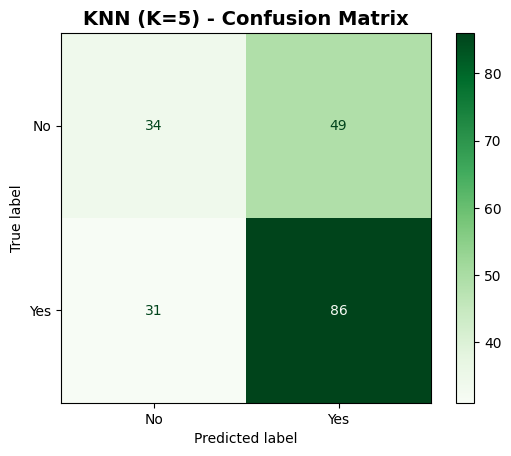


📋 Classification Report:
              precision    recall  f1-score   support

          No       0.52      0.41      0.46        83
         Yes       0.64      0.74      0.68       117

    accuracy                           0.60       200
   macro avg       0.58      0.57      0.57       200
weighted avg       0.59      0.60      0.59       200



In [17]:
# ============================================================
# STEP 16: Make KNN Predictions
# ============================================================

# Predict
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)

# Calculate accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("📈 KNN Performance (K=5)")
print("=" * 60)
print(f"\n🎯 Accuracy: {accuracy_knn:.4f} ({accuracy_knn*100:.2f}%)")

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(cm_knn, display_labels=['No', 'Yes']).plot(cmap='Greens')
plt.title('KNN (K=5) - Confusion Matrix', fontweight='bold', fontsize=14)
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['No', 'Yes']))

In [18]:
# ============================================================
# STEP 17: Finding the Optimal K
# ============================================================
# Different values of K can dramatically affect performance!

print("🔍 Finding Optimal K Value")
print("=" * 60)

# Test K values from 1 to 30
k_range = range(1, 31)
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, knn_temp.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, knn_temp.predict(X_test_scaled))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Find best K
best_k = k_range[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)

print(f"\n🏆 Best K: {best_k}")
print(f"   Best Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

🔍 Finding Optimal K Value

🏆 Best K: 25
   Best Test Accuracy: 0.6450 (64.50%)


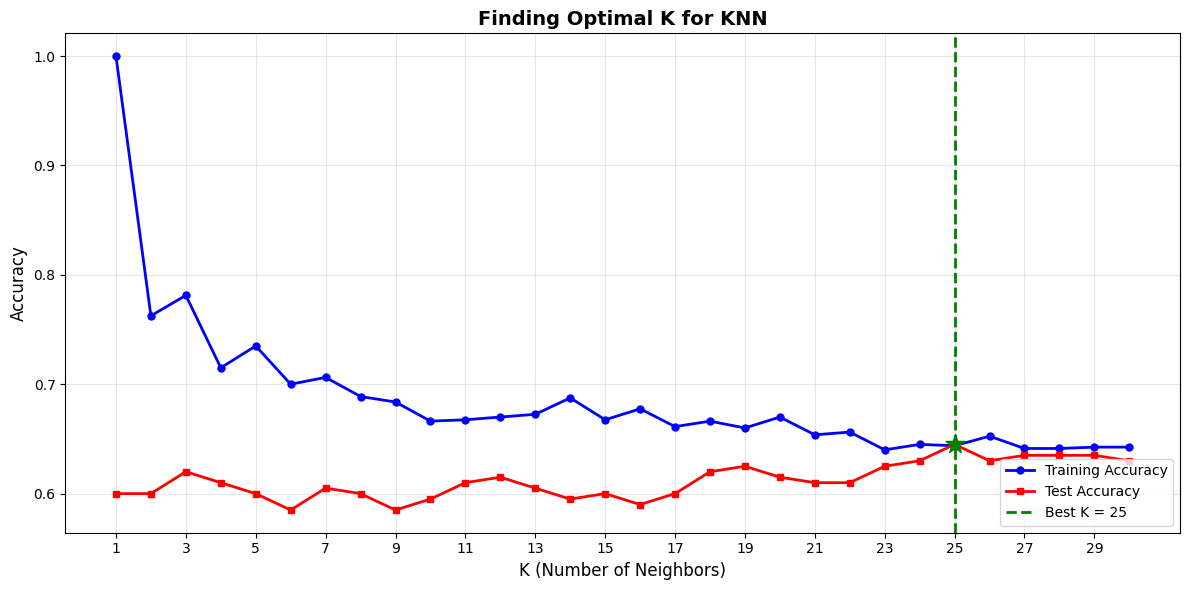


💡 Observations:
   • K=1: Overfitting (high training, lower test accuracy)
   • Very large K: Underfitting (model becomes too simple)
   • K=25: Best balance between bias and variance


In [19]:
# ============================================================
# STEP 18: Visualize K vs Accuracy
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(k_range, train_accuracies, 'b-o', label='Training Accuracy', linewidth=2, markersize=5)
plt.plot(k_range, test_accuracies, 'r-s', label='Test Accuracy', linewidth=2, markersize=5)

# Mark best K
plt.axvline(x=best_k, color='green', linestyle='--', linewidth=2, label=f'Best K = {best_k}')
plt.scatter([best_k], [best_accuracy], color='green', s=200, zorder=5, marker='*')

plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Finding Optimal K for KNN', fontweight='bold', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 31, 2))
plt.tight_layout()
plt.show()

print("\n💡 Observations:")
print("   • K=1: Overfitting (high training, lower test accuracy)")
print("   • Very large K: Underfitting (model becomes too simple)")
print(f"   • K={best_k}: Best balance between bias and variance")

In [20]:
# ============================================================
# STEP 19: Train Final KNN Model with Optimal K
# ============================================================

print(f"🎯 Training Final KNN Model with K={best_k}")
print("=" * 60)

# Train with optimal K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

# Final predictions
y_pred_knn_best = knn_best.predict(X_test_scaled)
accuracy_knn_best = accuracy_score(y_test, y_pred_knn_best)

print(f"\n✅ Final KNN Accuracy: {accuracy_knn_best:.4f} ({accuracy_knn_best*100:.2f}%)")

🎯 Training Final KNN Model with K=25

✅ Final KNN Accuracy: 0.6450 (64.50%)


## Part 5: Model Comparison

In [21]:
# ============================================================
# STEP 20: Compare Logistic Regression vs KNN
# ============================================================

print("🏁 Model Comparison")
print("=" * 60)

# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', f'KNN (K={best_k})'],
    'Accuracy': [accuracy_log, accuracy_knn_best],
    'Accuracy %': [f'{accuracy_log*100:.2f}%', f'{accuracy_knn_best*100:.2f}%']
})

print("\n📊 Accuracy Comparison:")
print(comparison.to_string(index=False))

# Winner
if accuracy_log > accuracy_knn_best:
    print("\n🏆 Winner: Logistic Regression")
elif accuracy_knn_best > accuracy_log:
    print(f"\n🏆 Winner: KNN (K={best_k})")
else:
    print("\n🤝 It's a tie!")

🏁 Model Comparison

📊 Accuracy Comparison:
              Model  Accuracy Accuracy %
Logistic Regression     0.640     64.00%
         KNN (K=25)     0.645     64.50%

🏆 Winner: KNN (K=25)


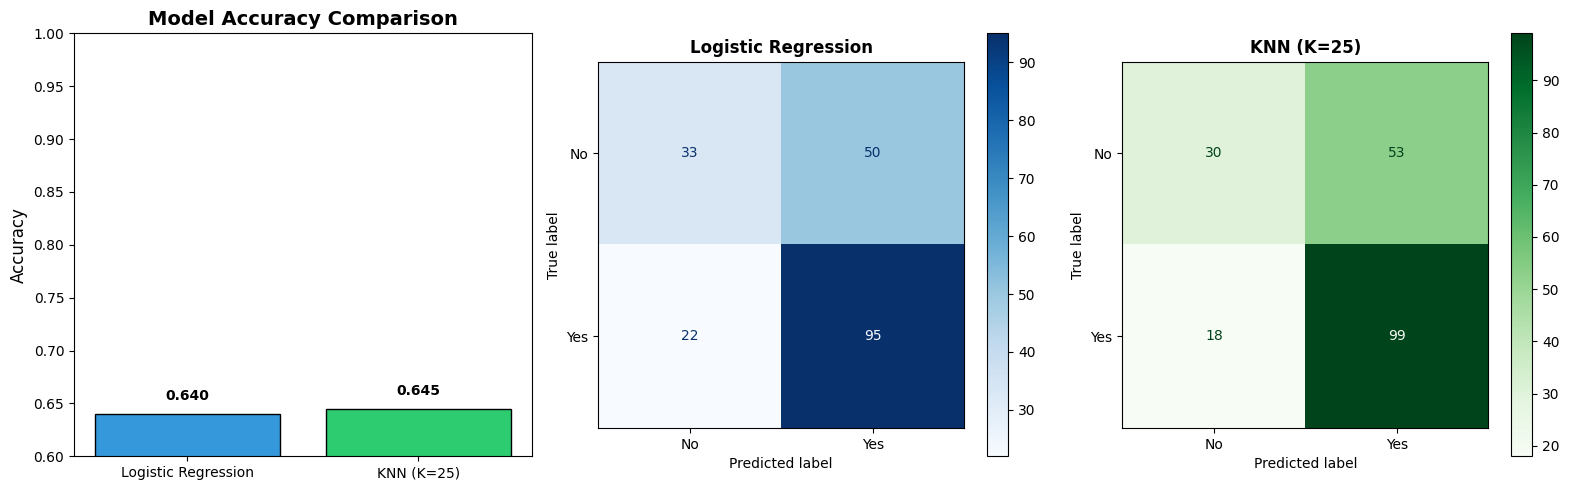

In [22]:
# ============================================================
# STEP 21: Visual Comparison
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart comparison
models = ['Logistic Regression', f'KNN (K={best_k})']
accuracies = [accuracy_log, accuracy_knn_best]
colors = ['#3498db', '#2ecc71']

bars = axes[0].bar(models, accuracies, color=colors, edgecolor='black')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=14)
axes[0].set_ylim(0.6, 1.0)

# Add value labels
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# Confusion matrices side by side
ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Logistic Regression', fontweight='bold')

cm_knn_best = confusion_matrix(y_test, y_pred_knn_best)
ConfusionMatrixDisplay(cm_knn_best, display_labels=['No', 'Yes']).plot(ax=axes[2], cmap='Greens')
axes[2].set_title(f'KNN (K={best_k})', fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# STEP 22: Model Characteristics Summary
# ============================================================

print("\n📋 Model Characteristics Summary")
print("=" * 70)
print("""
┌─────────────────────┬──────────────────────────┬──────────────────────────┐
│ Aspect              │ Logistic Regression      │ KNN                      │
├─────────────────────┼──────────────────────────┼──────────────────────────┤
│ Training Speed      │ Requires training        │ No training (lazy)       │
│ Prediction Speed    │ Very fast                │ Slow (calculates dist.)  │
│ Scalability         │ Excellent                │ Poor for large data      │
│ Interpretability    │ High (coefficients)      │ Low (black box)          │
│ Feature Scaling     │ Recommended              │ Required!                │
│ Decision Boundary   │ Linear                   │ Non-linear               │
│ Hyperparameters     │ Few                      │ K (crucial)              │
└─────────────────────┴──────────────────────────┴──────────────────────────┘
""")


📋 Model Characteristics Summary

┌─────────────────────┬──────────────────────────┬──────────────────────────┐
│ Aspect              │ Logistic Regression      │ KNN                      │
├─────────────────────┼──────────────────────────┼──────────────────────────┤
│ Training Speed      │ Requires training        │ No training (lazy)       │
│ Prediction Speed    │ Very fast                │ Slow (calculates dist.)  │
│ Scalability         │ Excellent                │ Poor for large data      │
│ Interpretability    │ High (coefficients)      │ Low (black box)          │
│ Feature Scaling     │ Recommended              │ Required!                │
│ Decision Boundary   │ Linear                   │ Non-linear               │
│ Hyperparameters     │ Few                      │ K (crucial)              │
└─────────────────────┴──────────────────────────┴──────────────────────────┘



In [24]:
# ============================================================
# 💡 YOUR TURN: Practice Exercises
# ============================================================

print("🏋️ Practice Exercises")
print("=" * 60)
print("""
Exercise 1: Try different distance metrics in KNN
  - Change 'euclidean' to 'manhattan' or 'chebyshev'
  - Compare the results

Exercise 2: Use a different threshold for Logistic Regression
  - Instead of 0.5, try 0.3 or 0.7
  - See how it affects precision vs recall

Exercise 3: Feature Selection
  - Try training with only the top 5 most important features
  - Does performance improve or decrease?

Uncomment the code below to start:
""")

# Exercise 1: Different KNN metrics
# knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
# knn_manhattan.fit(X_train_scaled, y_train)
# y_pred_manhattan = knn_manhattan.predict(X_test_scaled)
# print(f"Manhattan metric accuracy: {accuracy_score(y_test, y_pred_manhattan):.4f}")

🏋️ Practice Exercises

Exercise 1: Try different distance metrics in KNN
  - Change 'euclidean' to 'manhattan' or 'chebyshev'
  - Compare the results

Exercise 2: Use a different threshold for Logistic Regression
  - Instead of 0.5, try 0.3 or 0.7
  - See how it affects precision vs recall

Exercise 3: Feature Selection
  - Try training with only the top 5 most important features
  - Does performance improve or decrease?

Uncomment the code below to start:



## Part 6: Summary and Key Takeaways

### 🎯 What We Learned

1. **Logistic Regression**
   - Uses sigmoid function to output probabilities
   - Fast training and prediction
   - Interpretable through coefficients
   - Best for linearly separable data

2. **K-Nearest Neighbors**
   - No training phase (lazy learning)
   - Classifies based on neighbor voting
   - K must be tuned carefully
   - Feature scaling is essential!

3. **Model Evaluation**
   - Always use train/test split
   - Confusion matrix reveals more than accuracy
   - Consider the problem context when choosing models

### ⚠️ Key Points to Remember

- **Scale features** before applying these algorithms
- **Use odd K** in KNN to avoid ties
- **Logistic Regression for interpretability**, KNN for non-linear boundaries
- **Evaluate on test data**, not training data

---

**Next Lab:** Decision Trees & Random Forests 🌲🌳